In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd


In [47]:
# Hàm phân tích biến phân loại
from scipy.stats import chi2_contingency
from scipy import stats
def check_chi_square(df, col1, col2):
    """
    Hàm kiểm tra tính độc lập giữa 2 biến phân loại bằng Chi-Square.
    Nhằm phát hiện đa cộng tuyến phân loại.
    """
    # 1. Lập bảng tần suất chéo (Contingency Table) giữa 2 biến
    contingency_table = pd.crosstab(df[col1], df[col2])
    
    # 2. Chạy kiểm định Chi-Square
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table) # 
    
    # 3. In kết quả trực quan
    print(f"--- KIỂM ĐỊNH CHI-SQUARE: [{col1}] & [{col2}] ---")
    print(f"Giá trị thống kê χ² : {chi2_stat:.4f}")
    print(f"p-value             : {p_value:.4f}") # In ra p-value của kiểm định


def filter_by_anova_eta(df, cat_col, target_col):
    """
    Sử dụng kiểm định ANOVA và chỉ số Eta-squared (η²).
    """
    # Lọc bỏ các dòng có giá trị NaN ở 2 cột đang xét để hàm không bị lỗi
    valid_data = df[[cat_col, target_col]].dropna()
    
    # 1. CHUẨN BỊ DỮ LIỆU CHO ANOVA
    # Tách biến mục tiêu thành các mảng (arrays) riêng biệt theo từng nhóm phân loại
    groups = [group[target_col].values for name, group in valid_data.groupby(cat_col)]
    
    # 2. CHẠY KIỂM ĐỊNH ANOVA
    f_stat, p_value = stats.f_oneway(*groups)
    
    # 3. TÍNH TOÁN ETA-SQUARED (η²)
    # Tính trung bình của toàn bộ biến mục tiêu
    mean_total = valid_data[target_col].mean()
    
    # Tính Sum of Squares Total (SST)
    ss_total = ((valid_data[target_col] - mean_total) ** 2).sum()
    
    # Tính Sum of Squares Between (SSB)
    ss_between = 0
    for name, group in valid_data.groupby(cat_col):
        ss_between += len(group) * ((group[target_col].mean() - mean_total) ** 2)
        
    # Công thức Eta-squared
    eta_squared = ss_between / ss_total
    
    # 4. TRÌNH BÀY KẾT QUẢ
    print(f"--- ĐÁNH GIÁ BIẾN: [{cat_col}] tác động lên [{target_col}] ---")
    
    # In p-value (dùng định dạng số mũ e nếu quá nhỏ để tránh hiển thị 0.0000)

    print(f"p-value (ANOVA)  : {p_value:.4f} ")
    
    # In Eta-squared
    print(f"Eta-squared (η²) : {eta_squared:.4f}")


In [48]:
df = sns.load_dataset('tips')

In [49]:
df.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [51]:
print(df['day'].value_counts())
print(df['time'].value_counts())
print(df['size'].value_counts())
print(df['smoker'].value_counts())
print(df['sex'].value_counts())

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64
time
Dinner    176
Lunch      68
Name: count, dtype: int64
size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64
smoker
No     151
Yes     93
Name: count, dtype: int64
sex
Male      157
Female     87
Name: count, dtype: int64


## Phân tích biến liên tục

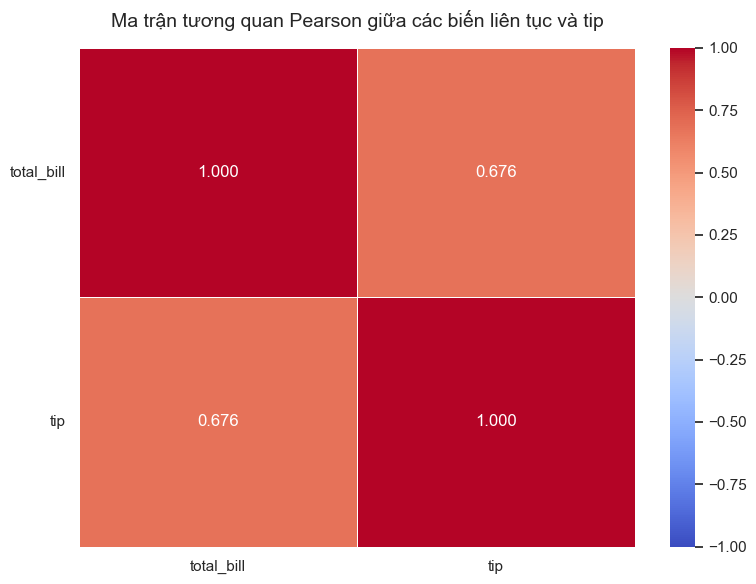

In [52]:
# 1. Xác định danh sách các biến liên tục và biến mục tiêu
continuous_features = ['total_bill']
target = 'tip'

# Gom tất cả vào một danh sách chung để tính ma trận tương quan
cols_to_corr = continuous_features + [target]

# 2. Tính toán ma trận tương quan Pearson từ DataFrame (df)
corr_matrix = df[cols_to_corr].corr()

# 3. Tiến hành cấu hình và vẽ biểu đồ Heatmap
plt.figure(figsize=(8, 6))

# Vẽ heatmap với các cấu hình tối ưu:
# - annot=True: Hiển thị giá trị số trên từng ô vuông
# - cmap='coolwarm': Bảng màu từ xanh (tương quan âm) sang đỏ (tương quan dương)
# - fmt=".3f": Làm tròn lấy 3 chữ số sau dấu phẩy
# - vmin=-1, vmax=1: Cố định dải màu chuẩn của hệ số tương quan từ -1 đến 1
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)

# Thay đổi tiêu đề và cách hiển thị
plt.title('Ma trận tương quan Pearson giữa các biến liên tục và tip', fontsize=14, pad=15)
plt.yticks(rotation=0)  # Giữ chữ trục tung nằm ngang cho dễ đọc

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## Tương quan khá tốt => Có giá trị 

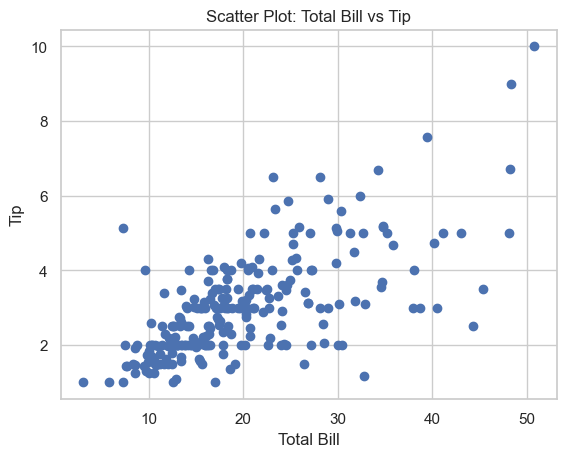

In [53]:
plt.scatter(df['total_bill'], df['tip'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Scatter Plot: Total Bill vs Tip')
plt.show()


## Có mối quan hệ -> total_bill càng cao thì tiếp càng cao

## Phân tích biến phân loại 

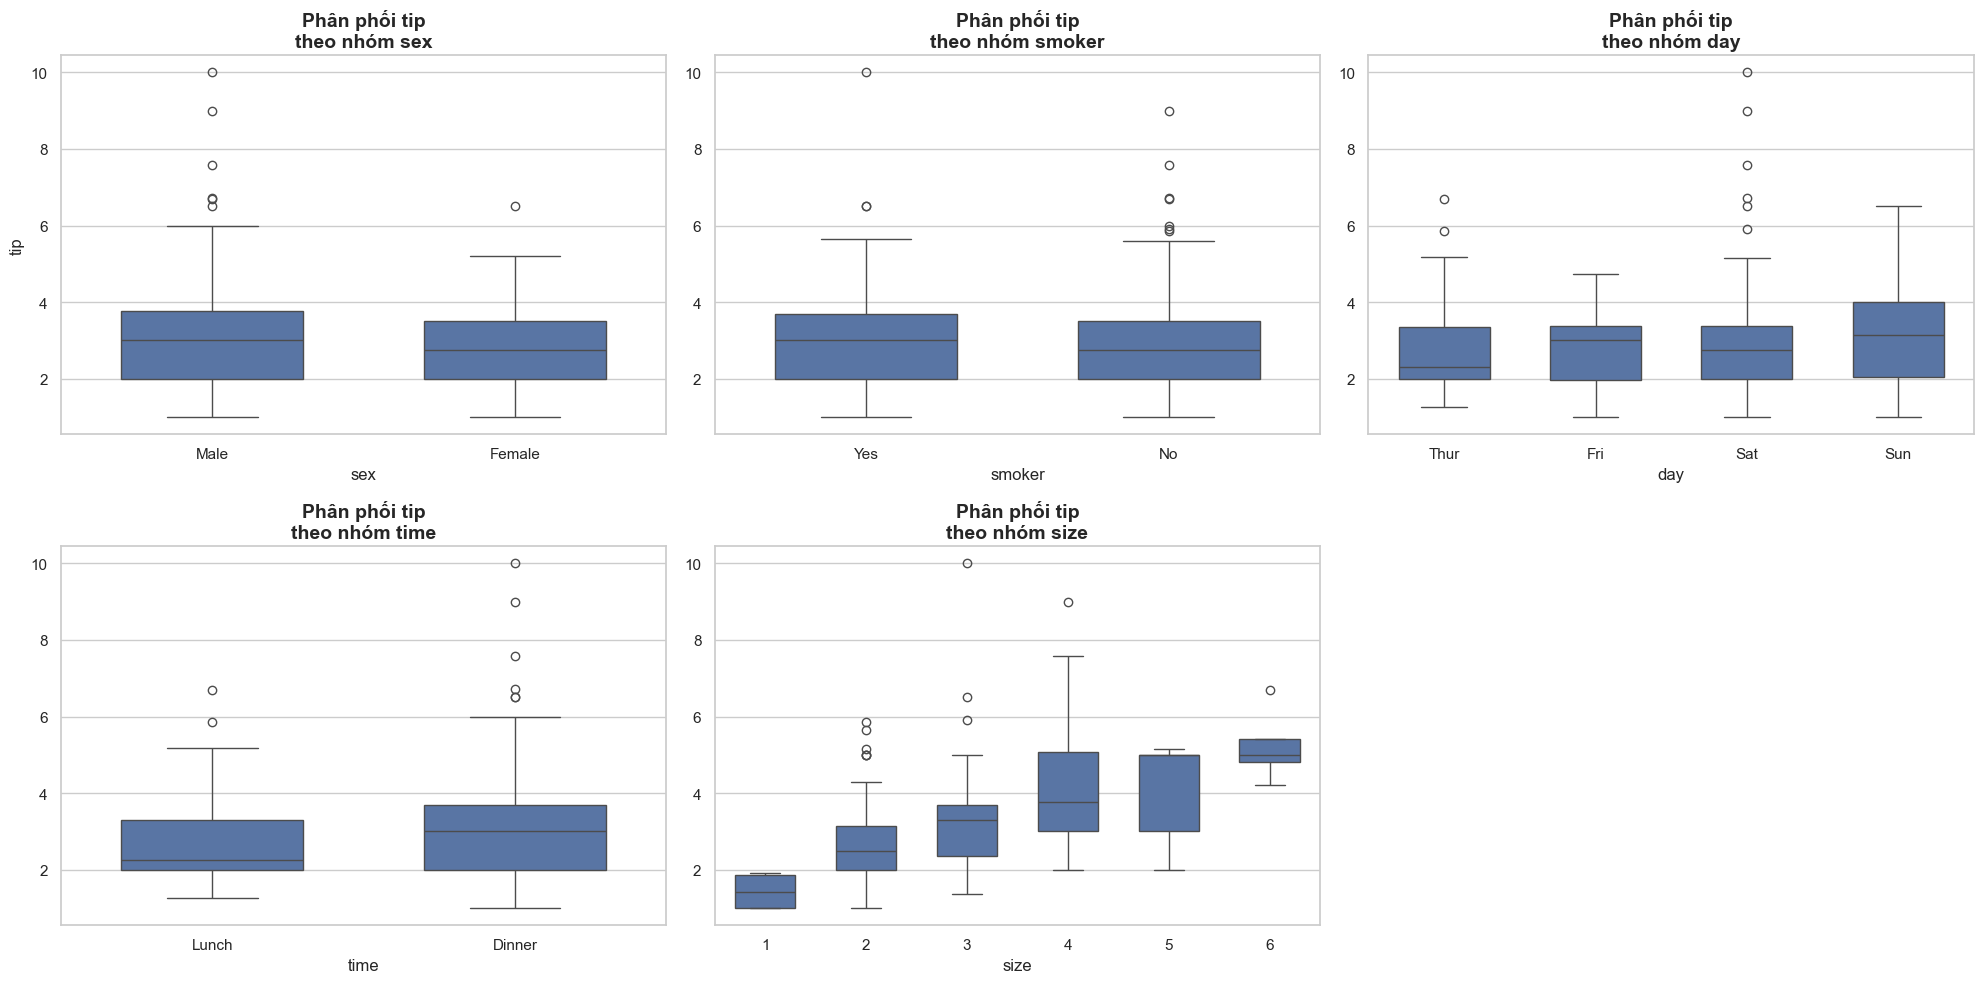

In [54]:

# Danh sách các biến phân loại cần vẽ (đã xác định là độc lập ở Bước 2)
cat_cols = ['sex', 'smoker', 'day', 'time', 'size']

# Định dạng thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid") # Nền trắng có lưới
plt.figure(figsize=(20, 10))      # Thiết lập kích thước khung tranh tổng thể (Rộng, Cao)

# Lặp qua từng biến phân loại để vẽ biểu đồ con (subplot)
for i, col in enumerate(cat_cols, 1):
    # Tạo subplot: 2 hàng, 3 cột, vị trí thứ i
    ax = plt.subplot(2, 3, i)
    
    # Vẽ Boxplot
    # x: Biến phân loại (nhóm)
    # y: Biến mục tiêu (số)
    sns.boxplot(x=col, y=target, data=df, width=0.6)
    
    
    # Trang trí cho từng biểu đồ con
    ax.set_title(f'Phân phối {target}\ntheo nhóm {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel(target if i == 1 else "", fontsize=12) # Chỉ hiện nhãn trục Y ở biểu đồ đầu tiên

# Tự động căn chỉnh khoảng cách giữa các biểu đồ để không bị đè chữ
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

## Thấy sự khác biệt với biếu đồ boxplot

In [55]:
for col in cat_cols:
    filter_by_anova_eta(df, col, target)

--- ĐÁNH GIÁ BIẾN: [sex] tác động lên [tip] ---
p-value (ANOVA)  : 0.1665 
Eta-squared (η²) : 0.0079
--- ĐÁNH GIÁ BIẾN: [smoker] tác động lên [tip] ---
p-value (ANOVA)  : 0.9266 
Eta-squared (η²) : 0.0000
--- ĐÁNH GIÁ BIẾN: [day] tác động lên [tip] ---
p-value (ANOVA)  : 0.1736 
Eta-squared (η²) : 0.0205
--- ĐÁNH GIÁ BIẾN: [time] tác động lên [tip] ---
p-value (ANOVA)  : 0.0578 
Eta-squared (η²) : 0.0148
--- ĐÁNH GIÁ BIẾN: [size] tác động lên [tip] ---
p-value (ANOVA)  : 0.0000 
Eta-squared (η²) : 0.2486


## Ho : Biến độc lập không liên quan đến biến mục tiêu
- size có p-value < 0.05 => Bác bỏ Ho 
## Xét Eta-squared đo lường tỷ lệ phần trăm sự biến thiên của  Tip được giải thích bởi biến phân loại.
- size tốt nhất trong các biến 

## Huấn luyện mô hình 

In [56]:
df_new = df[[ 'total_bill', 'size', 'tip' ]].copy()                   # R² Trung bình  : 0.3755  MAE Trung bình : 0.78
# df_new = df[[ 'total_bill', 'size', 'day', 'time', 'tip' ]].copy()  # R² Trung bình  : 0.3631  MAE Trung bình : 0.78

df_encoded = pd.get_dummies(df_new, columns=[ 'size'], drop_first=True, dtype=int)


In [57]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   size_2      244 non-null    int32  
 3   size_3      244 non-null    int32  
 4   size_4      244 non-null    int32  
 5   size_5      244 non-null    int32  
 6   size_6      244 non-null    int32  
dtypes: float64(2), int32(5)
memory usage: 8.7 KB


In [ ]:
# Tách đặc trưng (X) và mục tiêu (y)
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Tách đặc trưng (X) và mục tiêu (y)
X = df_encoded.drop(columns=['tip'])
y = df_encoded['tip']

# BẮT BUỘC: Thêm cột hằng số (constant) để tính hệ số chặn Intercept (Beta 0)
X_with_const = sm.add_constant(X)

# =====================================================================
# BƯỚC 2: CẤU HÌNH KFOLD STANDARD (Dành cho bài toán hồi quy liên tục)
# =====================================================================
n_splits = 5
# Thay thế StratifiedKFold bằng KFold vì dữ liệu hiện tại hoàn toàn là số thực/số nguyên
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

mae_scores = []
r2_scores = []

print(f"--- BẮT ĐẦU CHẠY OLS VỚI {n_splits}-FOLD CROSS VALIDATION ---\n")

# KFold thông thường chỉ cần truyền X_with_const vào hàm split
for fold, (train_idx, test_idx) in enumerate(kf.split(X_with_const), 1):
    
    # Chia dữ liệu theo chỉ số dòng
    X_train, X_test = X_with_const.iloc[train_idx], X_with_const.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # -----------------------------------------------------------------
    # BƯỚC 3: HUẤN LUYỆN MÔ HÌNH OLS
    # -----------------------------------------------------------------
    ols_model = sm.OLS(y_train, X_train).fit()
    
    # Dự đoán trên tập kiểm thử của Fold hiện tại
    y_pred = ols_model.predict(X_test)
    
    # Đánh giá hiệu suất
    fold_mae = mean_absolute_error(y_test, y_pred)
    fold_r2 = r2_score(y_test, y_pred)
    
    mae_scores.append(fold_mae)
    r2_scores.append(fold_r2)
    
    print(f"Fold {fold}: R² = {fold_r2:.4f} | MAE = {fold_mae:,.2f}")
    
    # In bảng báo cáo chi tiết cho 1 Fold 
    if fold == n_splits:
        print("\n" + "="*30 + " BẢNG BÁO CÁO CHI TIẾT OLS " + "="*30)
        print(ols_model.summary())
        print("="*99)
 
# =====================================================================
# BƯỚC 4: TỔNG HỢP HIỆU SUẤT TRUNG BÌNH
# =====================================================================
print("\n" + "="*50)
print("KẾT LUẬN HIỆU SUẤT TRUNG BÌNH QỦA CÁC FOLDS:")
print(f"-> R² Trung bình  : {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})")
print(f"-> MAE Trung bình : {np.mean(mae_scores):,.2f}")
print("="*50)

--- BẮT ĐẦU CHẠY OLS VỚI 5-FOLD CROSS VALIDATION ---

Fold 1: R² = 0.4571 | MAE = 0.67
Fold 2: R² = 0.0782 | MAE = 0.82
Fold 3: R² = 0.5560 | MAE = 0.69
Fold 4: R² = 0.4726 | MAE = 0.75
Fold 5: R² = 0.3138 | MAE = 0.96

============================== BẢNG BÁO CÁO CHI TIẾT OLS ==============================
                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     33.01
Date:                Fri, 29 May 2026   Prob (F-statistic):           4.70e-27
Time:                        11:48:59   Log-Likelihood:                -265.48
No. Observations:                 196   AIC:                             545.0
Df Residuals:                     189   BIC:                             567.9
Df Model:                           6                       

## Hệ số chặn: const 
- Nếu các biến độc lập không tác động thì tiền tip dự kiến sẽ là 0.7724
## Biến liên tục: total_bill
- Trong điều kiện các yếu tố khác không đổi, thì khi giá trị hóa đơn (total_bill) tăng thêm 1 USD thì tiền tip ước lượng sẽ tăng thêm khoảng 0.092
## Nhóm biến giả quy mô bàn ăn: size_2 đến size_6
- Trong điều kiện các yếu tố khác không đổi, thì khi tăng size_2 đến size_6 1 đơn vị thì tiền tip sẽ tăng lần lượt 0.3002,  0.6292, 0.6088,  1.0105, 1.2542

## Ho : Mô hình không phù hợp với dữ liệu 
- p-value là Prob 4.70e-27 < 0.05 => Bác bỏ Ho => mô hình phù hợp với dữ liệu